Estimated mean:
[10.1139643  20.09955843]

Estimated covariance:
[[4.1205694  0.01513261]
 [0.01513261 8.32212899]]

Mahalanobis distance² = 7.828
Mahalanobis distance  = 2.798

Chi² threshold = 9.210
NORMAL


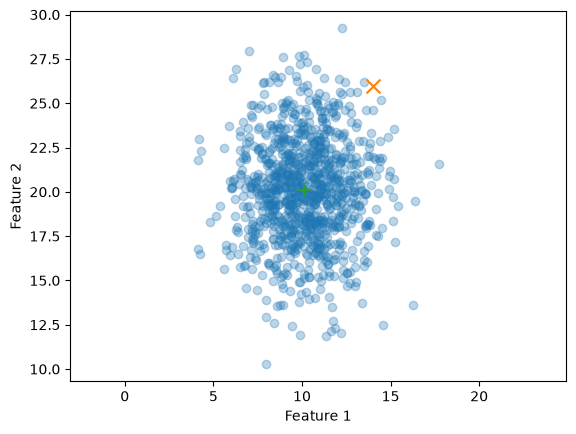

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# --------------------------------------------------
# 1. Generate random Gaussian training data
# --------------------------------------------------

np.random.seed(42)

mu_true = np.array([10, 20])

Sigma_true = np.array([
    [4, 0],
    [0, 9]
])

X = np.random.multivariate_normal(
    mean=mu_true,
    cov=Sigma_true,
    size=1000
)

# --------------------------------------------------
# 2. Estimate mean and covariance from the data
# --------------------------------------------------

mu = X.mean(axis=0)
Sigma = np.cov(X, rowvar=False)

print("Estimated mean:")
print(mu)

print("\nEstimated covariance:")
print(Sigma)

# --------------------------------------------------
# 3. Generate a new observation
# --------------------------------------------------

x = np.array([14, 26])

# --------------------------------------------------
# 4. Calculate Mahalanobis distance
# --------------------------------------------------

delta = x - mu

D2 = delta.T @ np.linalg.solve(Sigma, delta)
D = np.sqrt(D2)

print(f"\nMahalanobis distance² = {D2:.3f}")
print(f"Mahalanobis distance  = {D:.3f}")

# --------------------------------------------------
# 5. Choose 1% anomaly threshold
# --------------------------------------------------

alpha = 0.01
d = X.shape[1]

threshold = chi2.ppf(1 - alpha, df=d)

print(f"\nChi² threshold = {threshold:.3f}")

if D2 > threshold:
    print("ANOMALY")
else:
    print("NORMAL")

# --------------------------------------------------
# 6. Plot
# --------------------------------------------------

plt.scatter(X[:, 0], X[:, 1], alpha=0.3)

plt.scatter(
    x[0], x[1],
    s=100,
    marker='x'
)

plt.scatter(
    mu[0], mu[1],
    s=100,
    marker='+'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axis("equal")
plt.show()

In [7]:
normal = np.array([11, 22])
anomaly = np.array([18, 35])

for name, x in [("Normal", normal), ("Anomaly", anomaly)]:

    delta = x - mu
    D2 = delta.T @ np.linalg.solve(Sigma, delta)

    print(
        f"{name:8s}: "
        f"D² = {D2:6.2f}, "
        f"D = {np.sqrt(D2):5.2f}, "
        f"{'ANOMALY' if D2 > threshold else 'NORMAL'}"
    )

Normal  : D² =   0.62, D =  0.79, NORMAL
Anomaly : D² =  41.67, D =  6.46, ANOMALY
